In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("JAX_PLATFORMS", "cpu")

# Find repo root and add it to sys.path
_candidate_roots = [Path.cwd(), Path.cwd().parent]
for _root in _candidate_roots:
    if (_root / "pipeline").is_dir() and (_root / "config").is_dir():
        REPO_ROOT = _root
        if str(REPO_ROOT) not in sys.path:
            sys.path.insert(0, str(REPO_ROOT))
        break
else:
    raise FileNotFoundError("Could not locate repo root containing pipeline/ and config/")

print(f"Repo root: {REPO_ROOT}")


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

RUN_DIR = REPO_ROOT / "output/kelt20b/Duck24/transmission/2026-04-02_03-53-01"

posterior_path = RUN_DIR / "posterior_sample.npz"
summary_path = RUN_DIR / "mcmc_summary.txt"
atmo_path = RUN_DIR / "atmospheric_state.npz"
config_path = RUN_DIR / "run_config.log"

if not posterior_path.exists():
    raise FileNotFoundError(f"Missing posterior sample file: {posterior_path}")

posterior = np.load(posterior_path)
atmo = np.load(atmo_path) if atmo_path.exists() else None

display(Markdown(f"## HMC Run Directory\n`{RUN_DIR}`"))

print("=== MCMC summary ===")
print(summary_path.read_text())

print("\n=== Posterior keys ===")
print(posterior.files)

if atmo is not None:
    print("\n=== Atmospheric-state keys ===")
    print(atmo.files)
else:
    print("\nNo atmospheric_state.npz found.")

posterior_summary = pd.DataFrame(
    [
        {
            "parameter": name,
            "mean": float(np.mean(posterior[name])),
            "median": float(np.median(posterior[name])),
            "std": float(np.std(posterior[name])),
            "p05": float(np.percentile(posterior[name], 5)),
            "p95": float(np.percentile(posterior[name], 95)),
        }
        for name in posterior.files
        if np.asarray(posterior[name]).ndim >= 1
    ]
).sort_values("parameter", ignore_index=True)

display(posterior_summary)


## HMC Run Directory
`/home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-53-01`

=== MCMC summary ===

                    mean       std    median      5.0%     95.0%     n_eff     r_hat
            Kp    168.20      6.56    168.20    157.64    179.21     17.24      1.19
            Mp      3.39      0.10      3.39      3.23      3.54   1331.14      1.00
            Rp      1.74      0.10      1.73      1.59      1.90   1009.90      1.01
         Rstar      1.56      0.10      1.56      1.40      1.74   1274.72      1.00
          Tirr   2863.45     24.41   2863.90   2821.38   2901.54   1407.59      1.00
           dRV     -8.58      6.79     -6.33    -16.66     -0.80      3.08      4.18
         gamma     58.53     28.99     63.52     11.30     99.92     30.56      1.02
  kappa_ir_cgs      0.09      0.18      0.01      0.00      0.32    691.08      1.01
   logVMR_Fe I     -4.28      2.73     -3.20     -8.86     -2.00     12.90      1.16

Number of divergences: 0


=== Posterior keys ===
['Kp', 'Kp_kms', 'Mp', 'Rp', 'Rstar', 'Tirr', 'Vsys_kms', 'dRV', 'dRV_kms', '

,parameter,mean,median,std,p05,p95
0,Kp,168.196335,168.197327,6.561785,156.914773,178.704050
1,Kp_kms,168.196335,168.197327,6.561785,156.914773,178.704050
2,Mp,3.386400,3.386527,0.097909,3.225820,3.540927
3,Rp,1.735671,1.733299,0.095423,1.581871,1.893110
4,Rstar,1.563787,1.561403,0.104130,1.400688,1.738816
5,Tirr,2863.451660,2863.896240,24.408562,2821.362830,2901.530408
6,Vsys_kms,-22.780003,-22.780001,0.000002,-22.780001,-22.780001
7,dRV,-8.581533,-6.334309,6.788246,-16.333784,0.233051
8,dRV_kms,-8.581533,-6.334309,6.788246,-16.333784,0.233051
9,gamma,58.530357,63.520050,28.987299,0.224505,96.574797


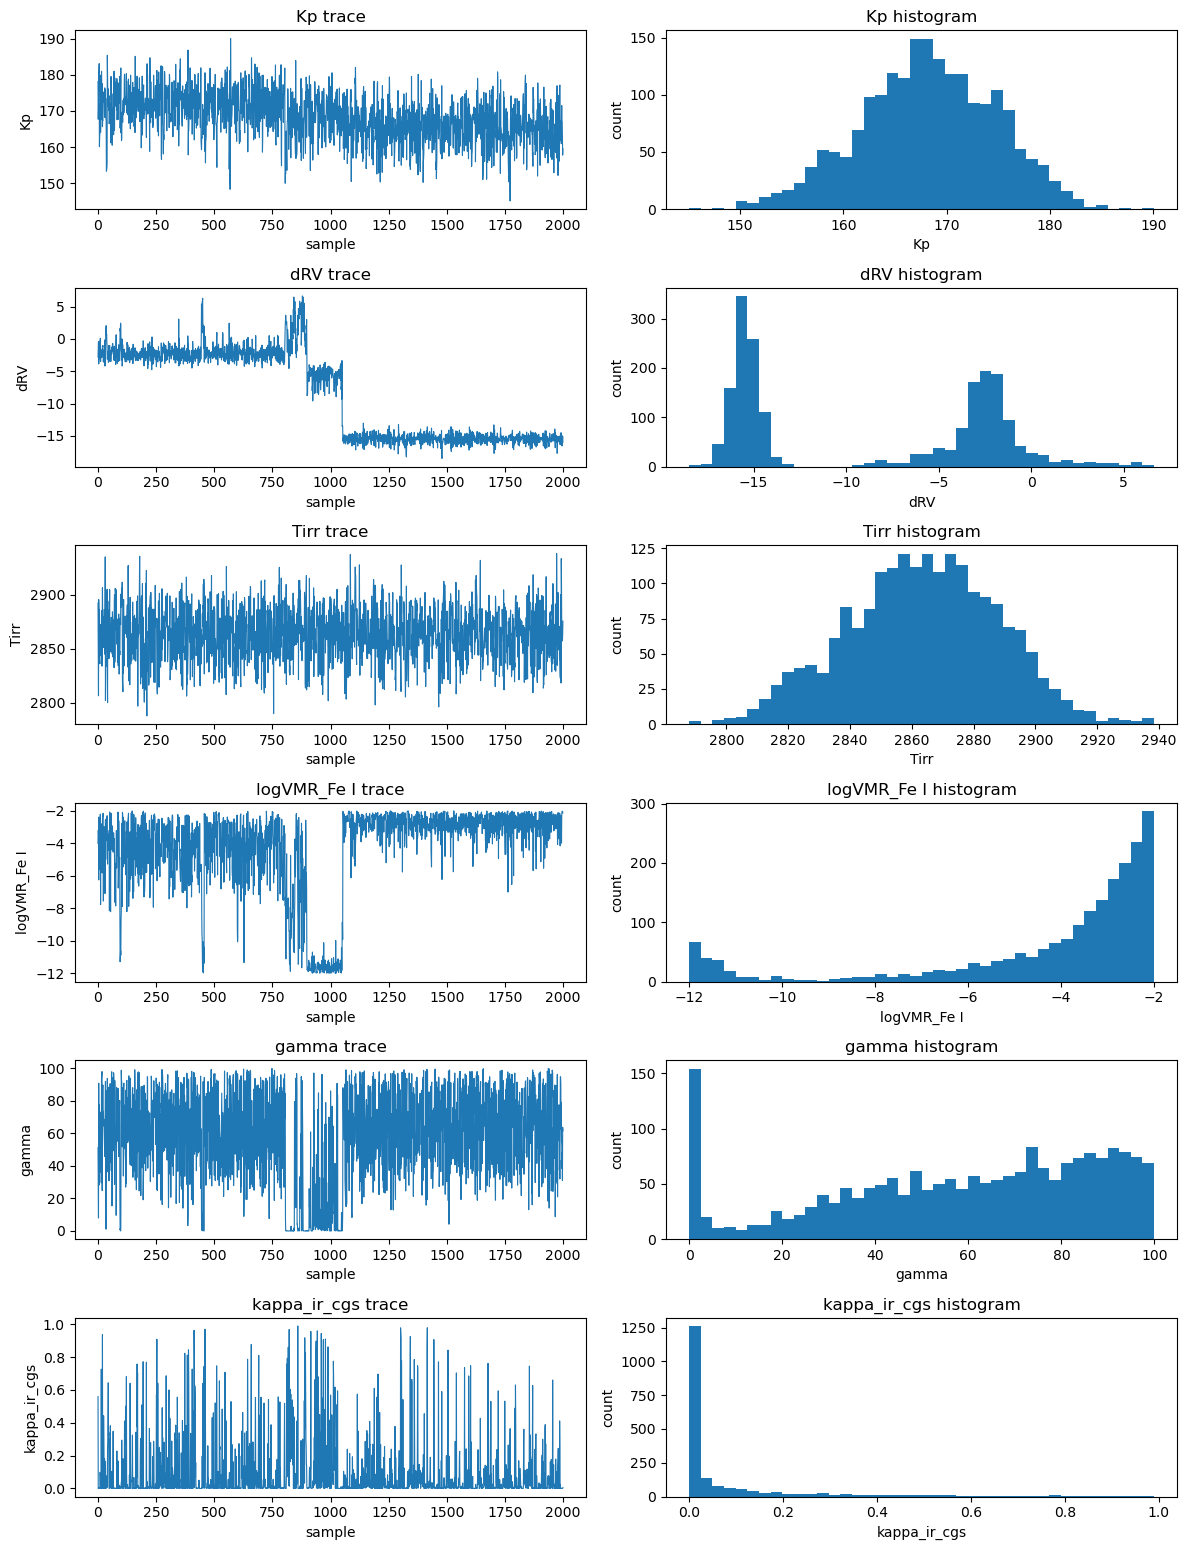

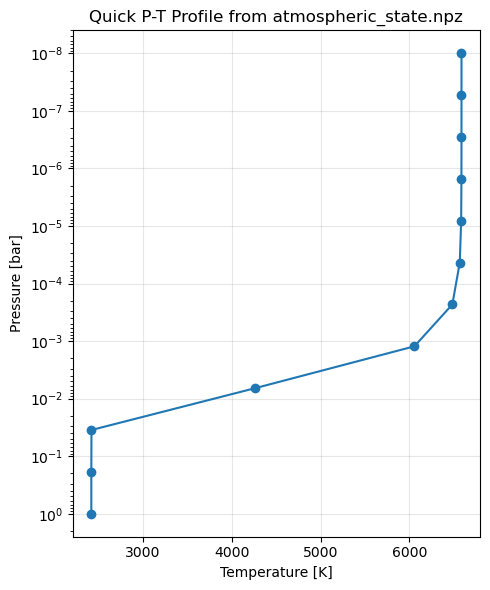

In [3]:
interesting = [
    "Kp",
    "dRV",
    "Tirr",
    "logVMR_Fe I",
    "gamma",
    "kappa_ir_cgs",
]

available = [name for name in interesting if name in posterior.files]

fig, axes = plt.subplots(len(available), 2, figsize=(12, 2.6 * len(available)), squeeze=False)

for row, name in enumerate(available):
    vals = np.asarray(posterior[name]).squeeze()

    axes[row, 0].plot(vals, lw=0.8)
    axes[row, 0].set_title(f"{name} trace")
    axes[row, 0].set_xlabel("sample")
    axes[row, 0].set_ylabel(name)

    axes[row, 1].hist(vals, bins=40)
    axes[row, 1].set_title(f"{name} histogram")
    axes[row, 1].set_xlabel(name)
    axes[row, 1].set_ylabel("count")

plt.tight_layout()
plt.show()

if atmo is not None and {"Tarr", "pressure"}.issubset(atmo.files):
    Tarr = np.asarray(atmo["Tarr"]).squeeze()
    pressure = np.asarray(atmo["pressure"]).squeeze()

    fig, ax = plt.subplots(figsize=(5, 6))
    ax.plot(Tarr, pressure, marker="o", lw=1.5)
    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.set_xlabel("Temperature [K]")
    ax.set_ylabel("Pressure [bar]")
    ax.set_title("Quick P-T Profile from atmospheric_state.npz")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Quick P-T plot unavailable because atmospheric_state.npz was not saved.")


Corner variables: ['Kp', 'dRV', 'Rp', 'Mp', 'Rstar', 'Tirr', 'kappa_ir_cgs', 'gamma', 'logVMR_Fe I']


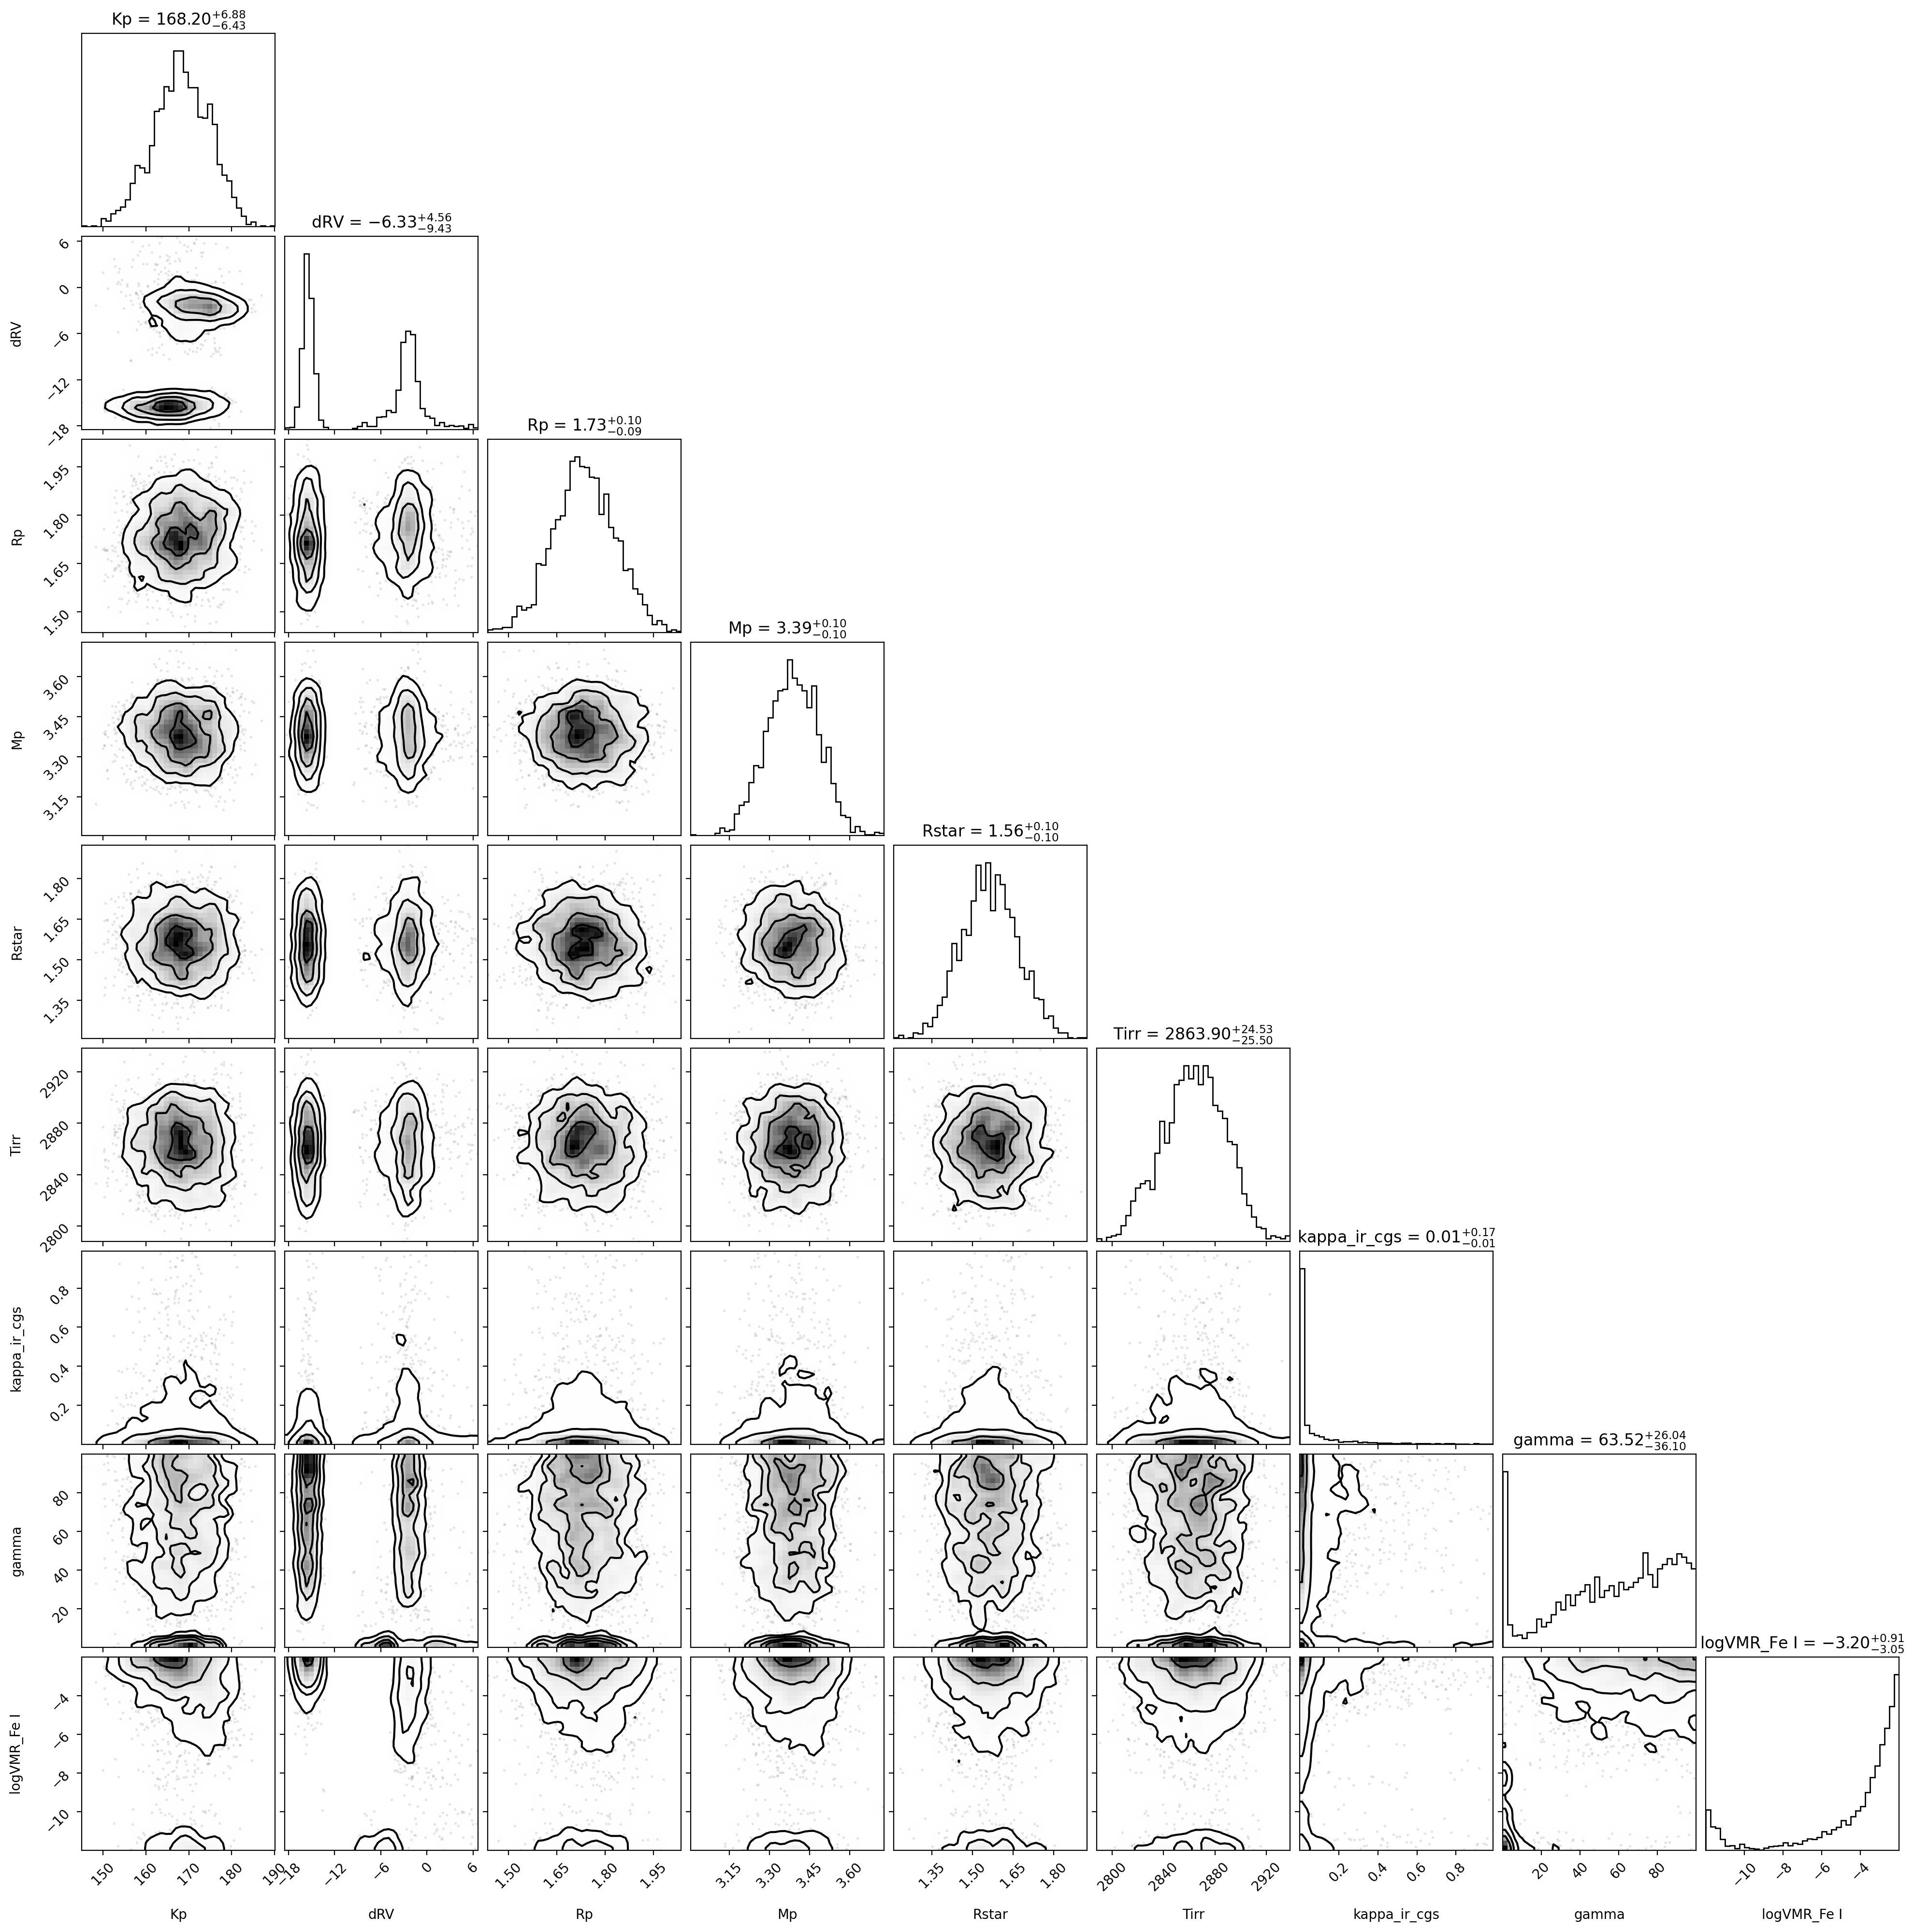

Saved to: /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-53-01/corner_plot_hmc_recreated.png


In [4]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import corner
from IPython.display import display
from PIL import Image as PILImage

RUN_DIR = REPO_ROOT / "output/kelt20b/Duck24/transmission/2026-04-02_03-53-01"
posterior = np.load(RUN_DIR / "posterior_sample.npz")

hmc_samples = {k: np.asarray(posterior[k]) for k in posterior.files}


def _is_corner_friendly(arr: np.ndarray) -> bool:
    arr = np.asarray(arr)
    return arr.ndim == 1 and arr.size > 1 and np.issubdtype(arr.dtype, np.number)


def _default_corner_variables(sample_dict: dict) -> list[str]:
    priority = [
        "Kp", "dRV", "dRV_0", "dRV_slope",
        "Rp", "Mp", "Rstar",
        "T0", "T_bottom", "T_top", "Tirr", "kappa_ir_cgs", "gamma",
        "T_deep", "log_P_trans", "delta_P",
        "log_metallicity", "C_O_ratio",
    ]
    skip_names = {
        "dRV_mean", "dRV_std", "dRV_at_ingress", "dRV_at_egress",
    }

    selected = []
    corner_ready = {
        name: np.asarray(values)
        for name, values in sample_dict.items()
        if _is_corner_friendly(np.asarray(values))
    }

    for name in priority:
        for key in sorted(corner_ready):
            base = key.split("/")[-1]
            if base == name and key not in selected:
                selected.append(key)

    for name in sorted(corner_ready):
        base = name.split("/")[-1]
        if base.startswith("logVMR_") and name not in selected:
            selected.append(name)

    for name in sorted(corner_ready):
        base = name.split("/")[-1]
        if name in selected or base in skip_names or base.endswith("_kms"):
            continue
        selected.append(name)

    return selected[:16]


corner_vars = _default_corner_variables(hmc_samples)
print("Corner variables:", corner_vars)

data = np.column_stack([np.asarray(hmc_samples[name]).ravel() for name in corner_vars])

fig = corner.corner(
    data,
    labels=corner_vars,
    bins=40,
    smooth=1.0,
    show_titles=True,
)

corner_path = RUN_DIR / "corner_plot_hmc_recreated.png"
fig.savefig(corner_path, dpi=200, bbox_inches="tight")
plt.close(fig)

display(PILImage.open(corner_path))
print(f"Saved to: {corner_path}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pipeline.diagnostics import build_diag_config_from_run_dir, build_primary_diagnostic_context
from physics.model import reconstruct_temperature_profile

posterior = np.load(RUN_DIR / "posterior_sample.npz")
posterior_np = {k: np.asarray(posterior[k]) for k in posterior.files}

if "ctx" not in globals():
    DIAG_CONFIG = build_diag_config_from_run_dir(
        RUN_DIR,
        epoch="20190504",
    )
    ctx = build_primary_diagnostic_context(
        **DIAG_CONFIG,
        apply_sysrem=True,
    )

art = ctx.primary_region_config.art
pt_profile = ctx.primary_region_config.pt_profile
Tint_fixed = ctx.primary_region_config.Tint_fixed
sample_prefix = ctx.primary_region_sample_prefix

fig, ax = plt.subplots(figsize=(6, 7))

sample_sizes = [
    np.asarray(v).shape[0]
    for v in posterior_np.values()
    if np.asarray(v).ndim > 0
]
n_samples = min(sample_sizes)
draw_count = min(100, n_samples)
draw_indices = np.random.choice(n_samples, draw_count, replace=False)

for idx in draw_indices:
    sample_params = {}
    for key, values in posterior_np.items():
        arr = np.asarray(values)
        sample_params[key] = arr if arr.ndim == 0 else arr[idx]

    Tarr = reconstruct_temperature_profile(
        sample_params,
        art,
        pt_profile=pt_profile,
        Tint_fixed=Tint_fixed,
        sample_prefix=sample_prefix,
    )
    ax.plot(np.asarray(Tarr), art.pressure, color="purple", alpha=0.08)

median_params = {}
for key, values in posterior_np.items():
    arr = np.asarray(values)
    median_params[key] = arr if arr.ndim == 0 else np.median(arr, axis=0)

Tarr_median = reconstruct_temperature_profile(
    median_params,
    art,
    pt_profile=pt_profile,
    Tint_fixed=Tint_fixed,
    sample_prefix=sample_prefix,
)

ax.plot(np.asarray(Tarr_median), art.pressure, color="black", lw=2)

ax.set_xlabel("T (K)")
ax.set_ylabel("P (bar)")
ax.set_yscale("log")
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
ax.set_title("Temperature-Pressure Profile from HMC Posterior")
plt.tight_layout()
plt.show()
